# Statistical Audit of pandas-dev/pandas

## Member Information
- **Name:** Ahmad Aqil Fadria
- **Role:** Data Engineer

---

# Research Questions

1. What is the estimated probability that a pull request gets merged in pandas-dev/pandas?

2. Has the average issue closing duration changed significantly after a major pandas release?

3. What is the probability that a randomly selected issue takes longer than 30 days to close?

---

# AI Usage Disclosure

**Member:** Ahmad Aqil Fadria — Data Engineer  
**Tools used:** ChatGPT

| Task | Tool | Prompt Summary | Output Modified? |
|---|---|---|---|
| GitHub API collection workflow | ChatGPT | GitHub issues API data collection | Yes |
| EDA notebook structure | ChatGPT | Statistical EDA notebook structure | Yes |

**Written entirely without AI:**
- Interpretation markdown cells
- EDA conclusions

---

# Import Libraries

In [94]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# GitHub API Configuration

This section defines the repository information and API endpoint
used to collect issue data from the pandas-dev/pandas repository.

In [95]:
OWNER = "pandas-dev"
REPO = "pandas"

BASE_URL = f"https://api.github.com/repos/{OWNER}/{REPO}/issues"

# Collect Issues Data

This section collects issue data from the GitHub REST API.
The dataset includes open and closed issues from the repository.

In [96]:
all_issues = []

for page in range(1, 6):

    url = (
        f"{BASE_URL}"
        f"?state=all&per_page=100&page={page}"
    )

    response = requests.get(url)

    if response.status_code != 200:
        print(f"Error collecting page {page}")
        break

    data = response.json()

    if len(data) == 0:
        break

    all_issues.extend(data)

    print(f"Collected page {page}")

Collected page 1
Collected page 2
Collected page 3
Collected page 4
Collected page 5


# Convert to DataFrame

The collected JSON data is converted into a pandas DataFrame
for further processing and analysis.

In [97]:
df = pd.DataFrame(all_issues)

print(df.shape)

(500, 37)


# Save Raw Dataset

The original dataset is saved without modification
to preserve the raw GitHub API data.

In [98]:
df.to_csv("../data/raw/issues_raw.csv", index=False)

print("Raw dataset saved.")

Raw dataset saved.


# Filter True Issues

The GitHub issues endpoint also contains pull requests.
This section filters only actual issues.

In [99]:
issues_df = df[df["pull_request"].isna()].copy()

# hanya issue closed
issues_df = issues_df[
    issues_df["state"] == "closed"
].copy()

print(issues_df.shape)

(21, 37)


# Select Important Columns

Only relevant columns are selected for statistical analysis.

In [100]:
issues_df = issues_df[
    [
        "id",
        "number",
        "title",
        "state",
        "created_at",
        "closed_at",
        "comments"
    ]
]

# Datetime Conversion

Datetime columns are converted into pandas datetime format
to enable duration analysis.

In [101]:
issues_df["created_at"] = pd.to_datetime(
    issues_df["created_at"]
)

issues_df["closed_at"] = pd.to_datetime(
    issues_df["closed_at"]
)

# Feature Engineering

This section creates new variables for statistical analysis.

In [102]:
issues_df["close_duration_days"] = (
    issues_df["closed_at"] - issues_df["created_at"]
).dt.days

issues_df["is_closed"] = 1

# Save Clean Dataset

The cleaned dataset is saved for use in
subsequent statistical analysis layers.

In [103]:
issues_df.to_csv(
    "../data/clean/dataset.csv",
    index=False
)

# Dataset Overview

This section provides a general overview
of the cleaned dataset.

In [104]:
issues_df.head()

,id,number,title,state,created_at,closed_at,comments,close_duration_days,is_closed
30,4477858094,65685,"BUG: Index.where(..., Index) fails on 3.1.0 bu...",closed,2026-05-19 13:39:44+00:00,2026-05-21 14:34:35+00:00,4,2,1
31,4475095354,65684,ENH: Add `df.corrupt()` accessor to inject ran...,closed,2026-05-19 06:52:43+00:00,2026-05-19 20:08:10+00:00,1,0,1
159,4412326774,65553,ENH: Improve missing column KeyError message i...,closed,2026-05-09 11:18:01+00:00,2026-05-09 16:23:27+00:00,1,0,1
162,4409913376,65550,BUG: `groupby` cumprod/cummin/cummax returns ...,closed,2026-05-08 22:56:54+00:00,2026-05-15 11:33:32+00:00,0,6,1
193,4403014478,65518,BUG: Conversion from np.ma.masked_array to pd....,closed,2026-05-08 01:11:36+00:00,2026-05-08 07:25:18+00:00,2,0,1


In [105]:
issues_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21 entries, 30 to 497
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype              
---  ------               --------------  -----              
 0   id                   21 non-null     int64              
 1   number               21 non-null     int64              
 2   title                21 non-null     object             
 3   state                21 non-null     object             
 4   created_at           21 non-null     datetime64[ns, UTC]
 5   closed_at            21 non-null     datetime64[ns, UTC]
 6   comments             21 non-null     int64              
 7   close_duration_days  21 non-null     int64              
 8   is_closed            21 non-null     int64              
dtypes: datetime64[ns, UTC](2), int64(5), object(2)
memory usage: 1.6+ KB


In [106]:
issues_df.describe()

,id,number,comments,close_duration_days,is_closed
count,2.100000e+01,21.000000,21.000000,21.000000,21.0
mean,4.340477e+09,65390.952381,2.095238,4.761905,1.0
std,6.967429e+07,148.808762,1.841325,5.384280,0.0
min,4.257146e+09,65213.000000,0.000000,0.000000,1.0
25%,4.264862e+09,65227.000000,1.000000,0.000000,1.0
50%,4.329508e+09,65369.000000,2.000000,2.000000,1.0
75%,4.385963e+09,65472.000000,3.000000,9.000000,1.0
max,4.477858e+09,65685.000000,6.000000,16.000000,1.0


# Missing Values Analysis

This section checks whether the dataset
contains missing values.

In [107]:
issues_df.isnull().sum()

id                     0
number                 0
title                  0
state                  0
created_at             0
closed_at              0
comments               0
close_duration_days    0
is_closed              0
dtype: int64

# Visualization: Closing Duration Distribution

This histogram shows the distribution
of issue closing duration in days.

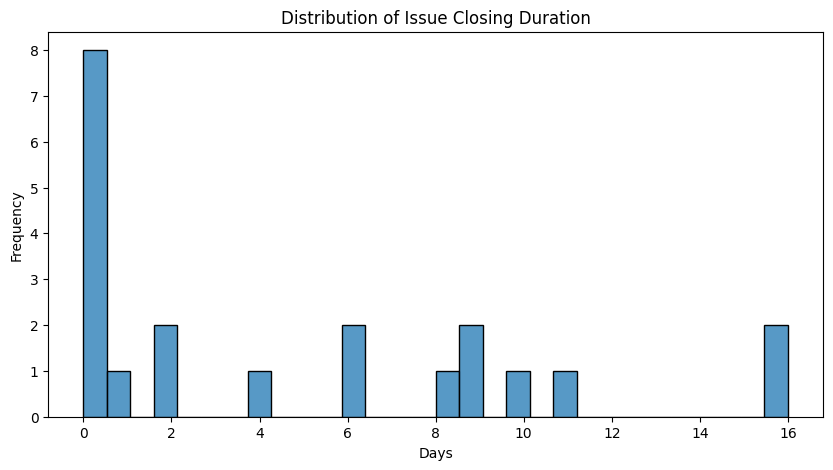

In [108]:
plt.figure(figsize=(10, 5))

sns.histplot(
    issues_df["close_duration_days"],
    bins=30
)

plt.title("Distribution of Issue Closing Duration")
plt.xlabel("Days")
plt.ylabel("Frequency")

plt.show()

# Visualization: Issue Status Count

This visualization compares the number
of open and closed issues.

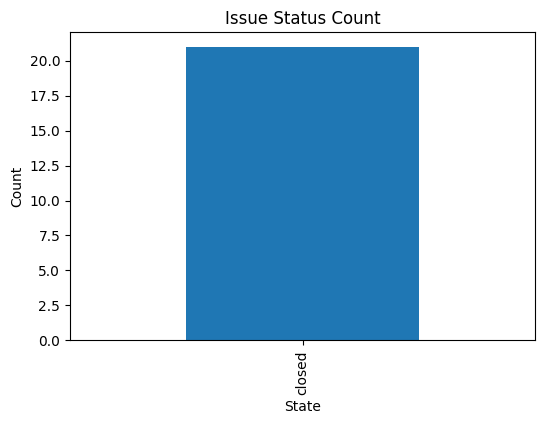

In [109]:
plt.figure(figsize=(6, 4))

issues_df["state"].value_counts().plot(
    kind="bar"
)

plt.title("Issue Status Count")
plt.xlabel("State")
plt.ylabel("Count")

plt.show()

# Visualization: Issues Created Over Time

This visualization shows issue activity trends over time.

C:\Users\USER\AppData\Local\Temp\ipykernel_19372\248647077.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .dt.to_period("M")


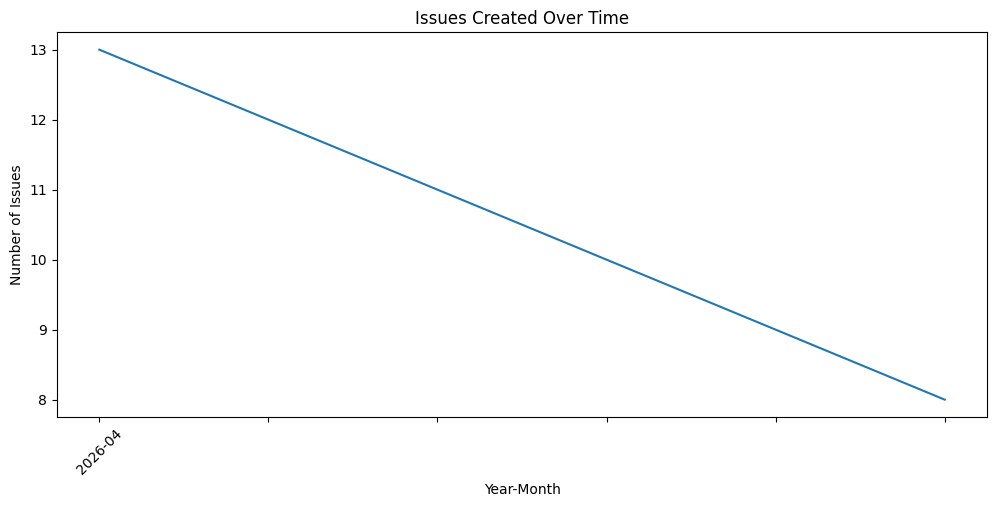

In [110]:
issues_df["year_month"] = (
    issues_df["created_at"]
    .dt.to_period("M")
    .astype(str)
)

monthly_issues = (
    issues_df["year_month"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(12, 5))

monthly_issues.plot()

plt.title("Issues Created Over Time")
plt.xlabel("Year-Month")
plt.ylabel("Number of Issues")

plt.xticks(rotation=45)

plt.show()

# Variable Selection

The following variables are selected
for subsequent statistical analysis.

In [111]:
variable_selection = pd.DataFrame({
    "Variable": [
        "is_closed",
        "close_duration_days",
        "comments"
    ],
    "Statistical Usage": [
        "Bernoulli Estimation",
        "Confidence Interval & Hypothesis Testing",
        "Poisson Analysis"
    ]
})

variable_selection

,Variable,Statistical Usage
0,is_closed,Bernoulli Estimation
1,close_duration_days,Confidence Interval & Hypothesis Testing
2,comments,Poisson Analysis


# Pull Request Data Collection

This section collects pull request data
from the pandas-dev/pandas repository
using the GitHub REST API.

The pull request dataset will later support:
- Bernoulli MLE
- merge probability estimation
- confidence interval construction
- statistical hypothesis testing

In [112]:
PR_URL = f"https://api.github.com/repos/{OWNER}/{REPO}/pulls"

all_prs = []

for page in range(1, 6):

    url = (
        f"{PR_URL}"
        f"?state=all&per_page=100&page={page}"
    )

    response = requests.get(url)

    if response.status_code != 200:
        print(f"Error collecting PR page {page}")
        break

    data = response.json()

    if len(data) == 0:
        break

    all_prs.extend(data)

    print(f"Collected PR page {page}")

print(f"Total PR collected: {len(all_prs)}")



Collected PR page 1
Collected PR page 2
Collected PR page 3
Collected PR page 4
Collected PR page 5
Total PR collected: 500


# Convert Pull Request Data to DataFrame

This section converts the collected pull request
JSON data into a pandas DataFrame for processing
and analysis.

In [113]:
pr_df = pd.DataFrame(all_prs)

print(pr_df.shape)

pr_df.head()

(500, 36)


,url,id,node_id,html_url,diff_url,patch_url,issue_url,number,state,locked,...,review_comment_url,comments_url,statuses_url,head,base,_links,author_association,auto_merge,assignee,active_lock_reason
0,https://api.github.com/repos/pandas-dev/pandas...,3736845357,PR_kwDOAA0YD87eu7wt,https://github.com/pandas-dev/pandas/pull/65717,https://github.com/pandas-dev/pandas/pull/6571...,https://github.com/pandas-dev/pandas/pull/6571...,https://api.github.com/repos/pandas-dev/pandas...,65717,open,False,...,https://api.github.com/repos/pandas-dev/pandas...,https://api.github.com/repos/pandas-dev/pandas...,https://api.github.com/repos/pandas-dev/pandas...,"{'label': 'pandas-dev:ci/update-pixi-lock', 'r...","{'label': 'pandas-dev:main', 'ref': 'main', 's...",{'self': {'href': 'https://api.github.com/repo...,CONTRIBUTOR,None,None,None
1,https://api.github.com/repos/pandas-dev/pandas...,3736266112,PR_kwDOAA0YD87esuWA,https://github.com/pandas-dev/pandas/pull/65716,https://github.com/pandas-dev/pandas/pull/6571...,https://github.com/pandas-dev/pandas/pull/6571...,https://api.github.com/repos/pandas-dev/pandas...,65716,closed,False,...,https://api.github.com/repos/pandas-dev/pandas...,https://api.github.com/repos/pandas-dev/pandas...,https://api.github.com/repos/pandas-dev/pandas...,{'label': 'hiraddlz:fix/update-warn-on-dtype-m...,"{'label': 'pandas-dev:main', 'ref': 'main', 's...",{'self': {'href': 'https://api.github.com/repo...,NONE,None,None,None
2,https://api.github.com/repos/pandas-dev/pandas...,3735916979,PR_kwDOAA0YD87erZGz,https://github.com/pandas-dev/pandas/pull/65715,https://github.com/pandas-dev/pandas/pull/6571...,https://github.com/pandas-dev/pandas/pull/6571...,https://api.github.com/repos/pandas-dev/pandas...,65715,open,False,...,https://api.github.com/repos/pandas-dev/pandas...,https://api.github.com/repos/pandas-dev/pandas...,https://api.github.com/repos/pandas-dev/pandas...,{'label': 'RonGamzu:doc/fix-where-mask-alignme...,"{'label': 'pandas-dev:main', 'ref': 'main', 's...",{'self': {'href': 'https://api.github.com/repo...,NONE,None,None,None
3,https://api.github.com/repos/pandas-dev/pandas...,3735897921,PR_kwDOAA0YD87erUdB,https://github.com/pandas-dev/pandas/pull/65714,https://github.com/pandas-dev/pandas/pull/6571...,https://github.com/pandas-dev/pandas/pull/6571...,https://api.github.com/repos/pandas-dev/pandas...,65714,open,False,...,https://api.github.com/repos/pandas-dev/pandas...,https://api.github.com/repos/pandas-dev/pandas...,https://api.github.com/repos/pandas-dev/pandas...,{'label': 'Sanjays2402:fix/melt-var-name-colli...,"{'label': 'pandas-dev:main', 'ref': 'main', 's...",{'self': {'href': 'https://api.github.com/repo...,NONE,None,None,None
4,https://api.github.com/repos/pandas-dev/pandas...,3734601797,PR_kwDOAA0YD87emYBF,https://github.com/pandas-dev/pandas/pull/65713,https://github.com/pandas-dev/pandas/pull/6571...,https://github.com/pandas-dev/pandas/pull/6571...,https://api.github.com/repos/pandas-dev/pandas...,65713,open,False,...,https://api.github.com/repos/pandas-dev/pandas...,https://api.github.com/repos/pandas-dev/pandas...,https://api.github.com/repos/pandas-dev/pandas...,{'label': 'puneetdixit200:fix/63832-path-serie...,"{'label': 'pandas-dev:main', 'ref': 'main', 's...",{'self': {'href': 'https://api.github.com/repo...,NONE,None,None,None


# Save Raw Pull Request Dataset

This section stores the original pull request dataset
without modification.

Output:
- data/raw/pull_requests_raw.csv

In [114]:
pr_df.to_csv(
    "../data/raw/pull_requests_raw.csv",
    index=False
)

print("pull_requests_raw.csv saved.")

pull_requests_raw.csv saved.


# Pull Request Data Cleaning

This section cleans the pull request dataset
and selects relevant variables for statistical analysis.

Cleaning includes:
- selecting relevant columns
- datetime conversion
- handling missing values
- feature engineering

In [115]:
pr_clean = pr_df[
    [
        "id",
        "number",
        "state",
        "created_at",
        "closed_at",
        "merged_at"
    ]
].copy()

print(pr_clean.shape)

pr_clean.head()

(500, 6)


,id,number,state,created_at,closed_at,merged_at
0,3736845357,65717,open,2026-05-24T05:34:32Z,None,None
1,3736266112,65716,closed,2026-05-23T23:05:41Z,2026-05-24T04:28:42Z,None
2,3735916979,65715,open,2026-05-23T19:32:56Z,None,None
3,3735897921,65714,open,2026-05-23T19:21:35Z,None,None
4,3734601797,65713,open,2026-05-23T10:19:50Z,None,None


# Datetime Conversion

This section converts timestamp variables
into datetime format for duration analysis
and statistical computation.

In [116]:
pr_clean["created_at"] = pd.to_datetime(
    pr_clean["created_at"]
)

pr_clean["closed_at"] = pd.to_datetime(
    pr_clean["closed_at"]
)

pr_clean["merged_at"] = pd.to_datetime(
    pr_clean["merged_at"]
)

# Pull Request Feature Engineering

This section creates additional variables
required for statistical analysis.

Generated variables:
- merged
- review_duration_days

In [117]:
# merged PR indicator
pr_clean["merged"] = (
    pr_clean["merged_at"].notna()
).astype(int)

# review duration
pr_clean["review_duration_days"] = (
    pr_clean["closed_at"] - pr_clean["created_at"]
).dt.days

pr_clean.head()

,id,number,state,created_at,closed_at,merged_at,merged,review_duration_days
0,3736845357,65717,open,2026-05-24 05:34:32+00:00,NaT,NaT,0,NaN
1,3736266112,65716,closed,2026-05-23 23:05:41+00:00,2026-05-24 04:28:42+00:00,NaT,0,0.0
2,3735916979,65715,open,2026-05-23 19:32:56+00:00,NaT,NaT,0,NaN
3,3735897921,65714,open,2026-05-23 19:21:35+00:00,NaT,NaT,0,NaN
4,3734601797,65713,open,2026-05-23 10:19:50+00:00,NaT,NaT,0,NaN


# Save Clean Pull Request Dataset

This section exports the cleaned pull request dataset
for use by subsequent statistical analysis layers.

Output:
- data/clean/pr_dataset.csv

In [118]:
pr_clean.to_csv(
    "../data/clean/pr_dataset.csv",
    index=False
)

print("pr_dataset.csv saved.")

pr_dataset.csv saved.


# Summary

The dataset has been successfully collected,
cleaned, and transformed into a format suitable
for statistical analysis.

The selected variables will support:
- parameter estimation
- confidence interval construction
- hypothesis testing
- computational simulation

This cleaned dataset will be used
by subsequent project members
for the next analytical layers.